In [1]:
import os
import sys
sys.path.insert(0, '../..')
import numpy as np
import matplotlib.pyplot as plt
import mssfp
import deepssfp
import deepssfp.analysis

In [2]:
mode = deepssfp.DataMode.SyntheticBanding.value
model_dir = "D:/DeepSSFP/"
model_name="water_phantom_T2maps"

100%|██████████| 8/8 [00:38<00:00,  4.79s/it]


Dataset loaded: (160, 416, 416, 16)
Memory size: 0.88604672 GB
Dataset shape: (160, 416, 416, 16)
Formatting data for SyntheticBanding mode...
Data format complete.
Input shape: (160, 416, 416, 8), Output shape: (160, 416, 416, 8)
Selected indices: [150  62]
Figure size: (16, 4)


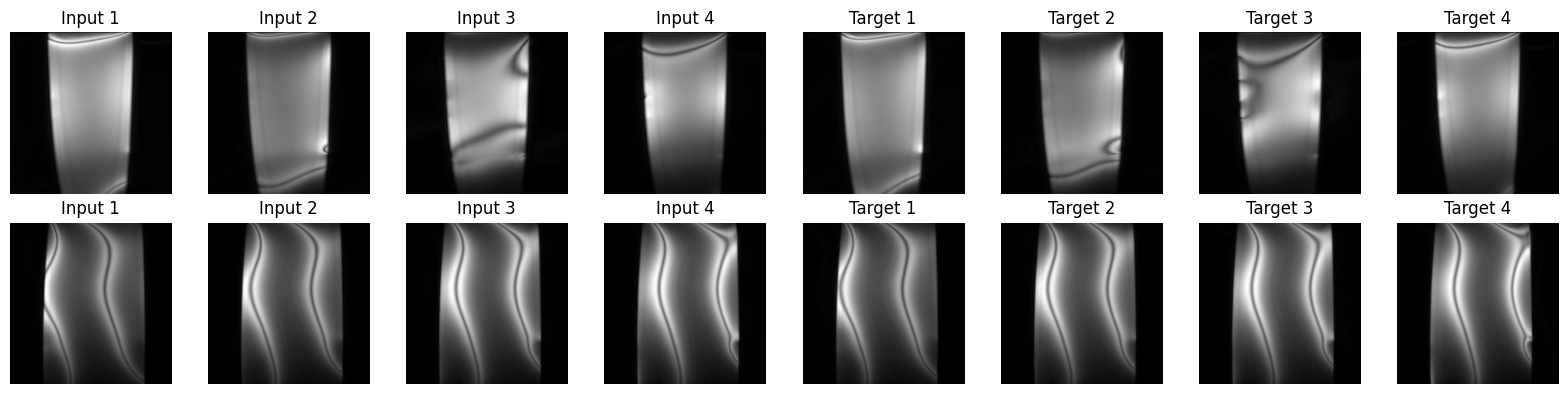

In [3]:
import deepssfp.dataloader
import deepssfp.dataformatter

path = 'D:/MRI/2025_04_23_DeepSSFP_T2_Phantom'
filters = ['grad']

dataset = deepssfp.dataloader.read_complex_dicom_datasets(path, filters = filters, data_format='RealImag', 
    folder_names=['pc_0', 'pc_45', 'pc_90', 'pc_135', 'pc_180', 'pc_225', 'pc_270', 'pc_315'])
print(f"Dataset shape: {dataset['M'].shape}")
input, output = deepssfp.dataformatter.format_synthetic_banding_for_realimag_data(dataset['M'])
print(f"Input shape: {input.shape}, Output shape: {output.shape}")

deepssfp.visualize_images(
    input_images=input,
    target_images=output,
    num_samples=2,
)

In [ ]:
import deepssfp.analysis
results = deepssfp.analysis.run_experiment(
    mode=deepssfp.DataMode.SyntheticBanding.value, 
    model_name=model_name,
    model_dir=model_dir,
    train_model=True,
    custom_dataset=dataset
)